/opt/anaconda3/lib/python3.8/site-packages/ipykernel/ipkernel.py:287: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



{'356857', '347997', '354939', '347597', '347692', '350272', '347320', '349350', '346699', '349985', '350986', '353643', '351260', '352425', '354176', '353401', '354270', '351123', '351312', '355485'}


  0%|          | 0/20 [00:00<?, ?it/s]

356857

    fixed : /dataset1/4dct_0510/resampled/356857_t5_resampled.nii
    moving: /dataset1/4dct_0510/resampled/356857_t0_resampled.nii
    ddf_r : /dataset1/4dct_0510/transform/356857_t5_Warp.nii.gz
    ddf_f : /home/zhaosheng/paper4/outputs/A2B_0512/39/ddfs/39_356857_ddf5.npy
    


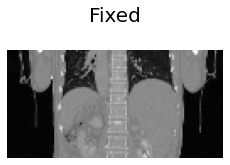

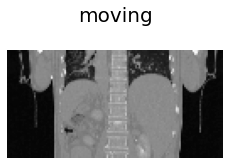

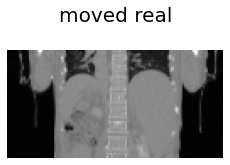

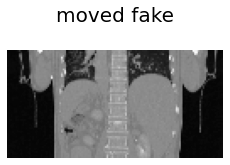

Error: Canceled future for execute_request message before replies were done

In [ ]:
import os
ddf_path = "/home/zhaosheng/paper4/r"
A2B_epoch = "159"
B2A_epoch = "119"

warp = Warp()
def sortddf(item):
    return item.split("/")[-1].split(".")[0].split("_ddf")[-1]

files = sorted([os.path.join(ddf_path,file) for file in os.listdir(ddf_path) if ".npy" in file])
pnames = set([file.split("/")[-1].split("_")[1] for file in files])

for pname in pnames:
    fake_ddfs_raw = sorted([file for file in files if pname in file],key=sortddf)
    fake_imgs = []
    real_imgs = []
    intput_imgs = []
    real_niis = []
    # real t0~t9
    for index in range(10):
        real_niis.append(f"/zhaosheng_data/4dct_2_test/{pname}/{pname}_t{index}.nii")
    
    # ddf1~ddf9
    for index in range(9):
        print(f"*Input:{fake_ddfs_raw[index]},{real_niis[0]},{real_niis[index+1]}\n")
        if index==4:
            plot=True
        else:
            plot=False
        ddf,moving_img,fixed_img,output_img = resample_dff(fake_ddfs_raw[index],real_niis[0],real_niis[index+1],warp,savepath="/home/zhaosheng/paper4/results_2",plot=plot)
        
        # fake t1~t9
        # if index==4:
        # fake_imgs.append(output_img)
        # real_imgs.append(fixed_img)
        # intput_imgs.append(moving_img)
        # break
    # print(fake_niis)
    # break


In [80]:
npy = np.load("/home/zhaosheng/paper4/result0502/199_pengmeidi_ddf5.npy")[0]
ddf_1 = []
for index in range(3):
    ddf_raw_1 = ants.from_numpy(npy[index])
    ddf_raw_1 = ants.resample_image(ddf_raw_1,moving_img.shape,True,4)
    ddf_1.append(ddf_raw_1.numpy())
ddf_1 = torch.tensor(np.array(ddf_1))

print(ddf_1.shape)

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


torch.Size([3, 512, 512, 144])


肿瘤体心 [183.56748306 307.1099531   34.82178218]
torch.Size([1, 1, 512, 512, 144])
torch.Size([1, 1, 512, 512, 144])
torch.Size([1, 1, 512, 512, 144])
torch.Size([1, 3, 512, 512, 144])
形变后肿瘤体心 Real：[  0.           0.         184.25636008 307.83561644  37.33365949]
形变后肿瘤体心 Fake：[  0.           0.         183.30055249 307.02983425  38.3679558 ]
torch.Size([1, 1, 512, 512, 144])
torch.Size([1, 1, 512, 512, 144])
torch.Size([1, 1, 512, 512, 144])


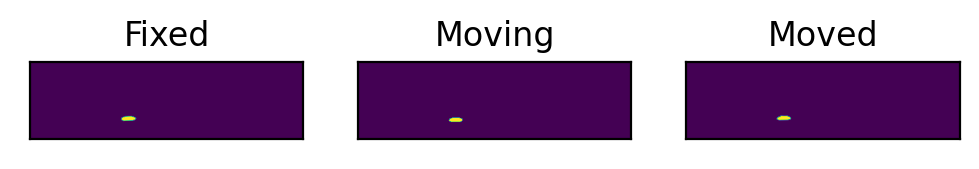

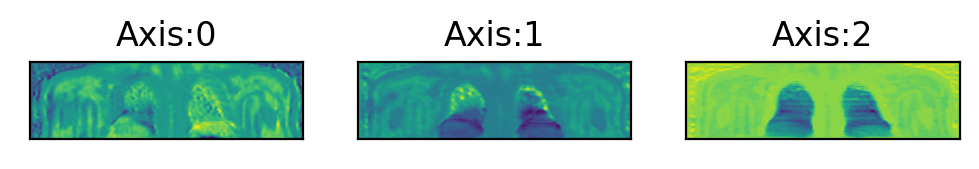

In [141]:
patient_name = "pengmeidi"



from shapely.geometry import Polygon


def getLoc(_npy):
    _npy = np.array(_npy)
    loc = np.mean(np.argwhere(_npy == 1),axis=0)
    return loc

tumor_base = torch.tensor(ants.image_read(f"/dataset1/4dct_test_tumor/{patient_name}.nrrd").numpy())
print(f"肿瘤体心 {getLoc(tumor_base)}")
tumor_base = torch.unsqueeze(tumor_base, dim=0)
tumor_base = torch.unsqueeze(tumor_base, dim=0)
print(tumor_base.shape)

moving = torch.tensor(ants.image_read("/home/zhaosheng/4dct_test_nii/pengmeidi/pengmeidi_t0.nii").numpy())
fixed = torch.tensor(ants.image_read("/home/zhaosheng/4dct_test_nii/pengmeidi/pengmeidi_t5.nii").numpy())
fake_ddf = torch.unsqueeze(ddf_1, dim=0)
real_ddf = torch.tensor(ants.image_read("/home/zhaosheng/4dct_test_nii_transform_SyNAggro/pengmeidi_t5.nii.gz").numpy().transpose(3,0,1,2))
real_ddf = torch.unsqueeze(real_ddf, dim=0)
moving = torch.unsqueeze(moving, dim=0)
moving = torch.unsqueeze(moving, dim=0)
fixed = torch.unsqueeze(fixed, dim=0)
fixed = torch.unsqueeze(fixed, dim=0)
print(moving.shape)
print(fixed.shape)
assert fake_ddf.shape == real_ddf.shape
print(fake_ddf.shape)
moved_real = warp(moving,real_ddf)
moved_fake = warp(moving,fake_ddf)
tumor_after_real = warp(tumor_base,real_ddf)
tumor_after_fake = warp(tumor_base,fake_ddf)
print(f"形变后肿瘤体心 Real：{getLoc(tumor_after_real)}")
print(f"形变后肿瘤体心 Fake：{getLoc(tumor_after_fake)}")


def plot(array,ax,title,tumor=None):
    img = array.numpy()[0,0,:,307,::-1].transpose(1,0)
    
    if tumor != None :
        print(tumor.shape)
        assert tumor.shape == array.shape,"Tumor size error"
        #img[(np.array(tumor)[0,0,:,307,::-1]).transpose(1,0)==1] = 3000
        img = (np.array(tumor)[0,0,:,307,::-1]).transpose(1,0)
    
    ax.imshow(img)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)
    return 0
def plot_ddf(array,ax,title):
    ax.imshow(array)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)
    return 0

def show_ddf(ddf):
    plt.figure(dpi=200)
    for index in range(3):
        plot_ddf(ddf.numpy()[0,index,:,307,::-1].transpose(1,0),plt.subplot(1,3,index+1),f"Axis:{index}")
    plt.show()
    
import matplotlib.pyplot as plt
# plt.figure(dpi=200)
# plot(fixed,plt.subplot(1,3,1),"Fixed",tumor_base)
# plot(moving,plt.subplot(1,3,2),"Moving",tumor_base)
# plot(moved_real,plt.subplot(1,3,3),"Moved",tumor_after_real)
# plt.show()

# show_ddf(real_ddf)


import matplotlib.pyplot as plt
plt.figure(dpi=200)
plot(fixed,plt.subplot(1,3,1),"Fixed",tumor_after_real)
plot(moving,plt.subplot(1,3,2),"Moving",tumor_base)
plot(moved_fake,plt.subplot(1,3,3),"Moved",tumor_after_fake)
plt.show()

show_ddf(fake_ddf)

In [132]:
patient_name = "pengmeidi"



from shapely.geometry import Polygon


def getLoc(_npy):
    _npy = np.array(_npy)
    loc = np.mean(np.argwhere(_npy == 1),axis=0)
    return loc

tumor_base = torch.tensor(ants.image_read(f"/dataset1/4dct_test_tumor/{patient_name}.nrrd").numpy())
print(f"肿瘤体心 {getLoc(tumor_base)}")
tumor_base = torch.unsqueeze(tumor_base, dim=0)
tumor_base = torch.unsqueeze(tumor_base, dim=0)
print(tumor_base.shape)

肿瘤体心 [183.56748306 307.1099531   34.82178218]
torch.Size([1, 1, 512, 512, 144])


In [133]:
tumor_base

tensor([[[[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]],

          [[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]],

          [[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]],

          ...,

          [[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           

monai.networks.blocks.Warp: Using PyTorch native grid_sample.


Loading tumor, Shape: {self.tumor_base.shape}
肿瘤体心 [  0.           0.         183.56748306 307.1099531   34.82178218]


In [2]:
from get_loc_results import Patient
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
plt.style.use('ggplot')

results = {}
for pname in tqdm(sorted([_file.split(".")[0] for _file in  os.listdir("/home/zhaosheng/4dct_test_nii")])[1:]):
    results[pname]={}
    test = Patient(pname,"/home/zhaosheng/paper4/results0505/")
    real_loc,fake_loc = test._getImage()
#     plt.figure(dpi=200)
#     plt.title(f"GTV location")
#     results[pname]["real_loc"] = real_loc
#     results[pname]["fake_loc"] = fake_loc
#     fake_loc = fake_loc - fake_loc[0]
#     real_loc = real_loc - real_loc[0]
#     # plt.plot(np.array(fake_loc)[:,-3],linewidth=3,label="X axis")
#     # plt.plot(np.array(real_loc)[:,-3],linewidth=3,label="X axis")

#     # plt.plot(np.array(fake_loc)[:,-2],linewidth=3,label="Y axis")
#     # plt.plot(np.array(real_loc)[:,-2],linewidth=3,label="Y axis")

#     plt.plot(np.array(fake_loc)[:,-1],linewidth=3,label="Z axis")
#     plt.plot(np.array(real_loc)[:,-1],linewidth=3,label="Z axis")

#     plt.legend()
#     plt.legend()
#     plt.show()
    

  0%|          | 0/17 [00:00<?, ?it/s]monai.networks.blocks.Warp: Using PyTorch native grid_sample.

  0%|          | 0/9 [00:00<?, ?it/s]

Get base Image: Success!



  0%|          | 0/9 [00:00<?, ?it/s]

Get base Image: Success!



  0%|          | 0/9 [00:00<?, ?it/s]

...


  0%|          | 0/9 [00:00<?, ?it/s]

Get base Image: Success!



  0%|          | 0/9 [00:00<?, ?it/s]

Get base Image: Success!



100%|██████████| 17/17 [1:06:28<00:00, 234.61s/it]


In [3]:
sorted([_file.split(".")[0] for _file in  os.listdir("/dataset1/4dct_test_tumor") if "nrrd" in _file])

['caowujun',
 'chenguangdeng',
 'chenjinsheng',
 'chenkemo',
 'chenshufang',
 'guixiufang',
 'hanjiangying',
 'hexiaochun',
 'huyannian',
 'huzhiwen',
 'jimeihong',
 'jinyurong',
 'liuwansheng',
 'liuyoukai',
 'liyifeng',
 'lubaimei',
 'lvqingcheng',
 'pengmeidi']